# EDA sobre el conjunto de entrenamiento

Análisis exploratorio restringido al conjunto Train para evitar contaminación de información del conjunto de evaluación. Se examinan valores faltantes, distribución de la gravedad del triaje, correlaciones entre constantes vitales y relaciones bivariantes con las etiquetas de resultado.

## Configuración y carga del conjunto de entrenamiento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Estilo visual para figuras de calidad de publicación
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

PROCESSED_DIR = Path("../../data/processed")
train_path = PROCESSED_DIR / "train.parquet"

print("Cargando conjunto de entrenamiento (Train)...")
df_train = pd.read_parquet(train_path)
print(f"Train shape: {df_train.shape[0]:,} estancias, {df_train.shape[1]} variables")

Cargando conjunto de entrenamiento (Train)...
Train shape: 278,320 estancias, 21 variables


## Análisis de valores faltantes en constantes vitales

La tasa de missingness en variables de triaje es relevante para decidir la estrategia de imputación y para evaluar el sesgo potencial si el patrón de ausencia no es aleatorio (MNAR).

C:\Users\cuent\AppData\Local\Temp\ipykernel_22120\3313254783.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=missing_data.values, y=missing_data.index, palette="mako")


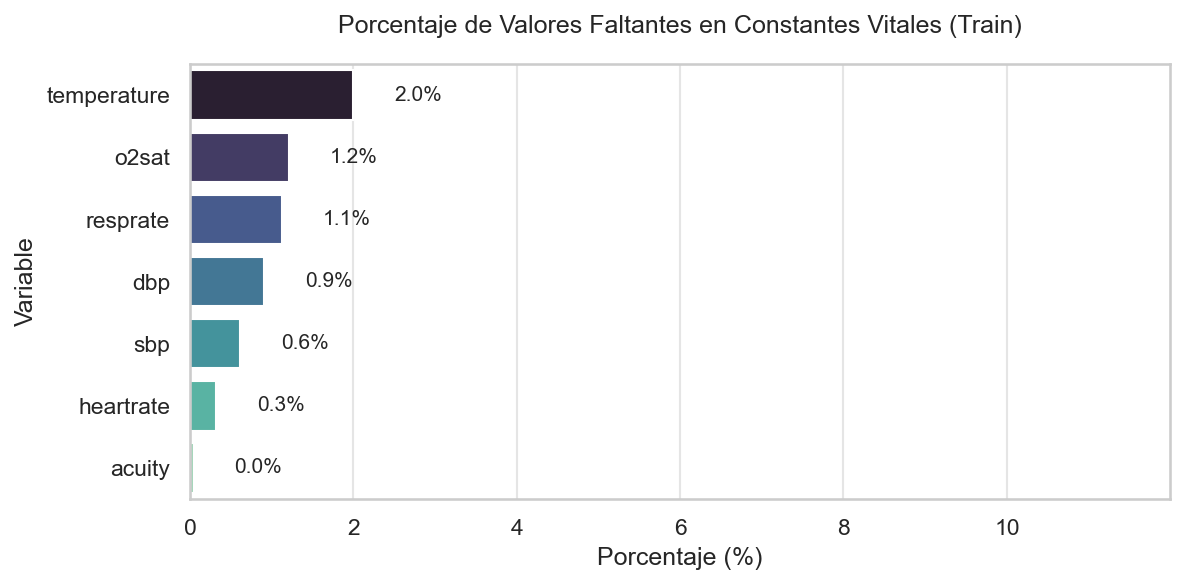

In [2]:
vitals_cols = ["temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp", "acuity"]

missing_data = df_train[vitals_cols].isnull().mean() * 100
missing_data = missing_data.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=missing_data.values, y=missing_data.index, palette="mako")
plt.title("Porcentaje de Valores Faltantes en Constantes Vitales (Train)", pad=15)
plt.xlabel("Porcentaje (%)")
plt.ylabel("Variable")

for patch in ax.patches:
    width = patch.get_width()
    plt.text(width + 0.5, patch.get_y() + patch.get_height()/2, f'{width:.1f}%', va='center')

plt.xlim(0, max(missing_data.values) + 10)
plt.tight_layout()
plt.show()

## Distribución del nivel de triaje (Acuity/ESI)

La distribución de acuity refleja el perfil de gravedad del servicio de urgencias. El nivel 1 corresponde a los pacientes más críticos y tiene implicaciones directas en el desbalance de las etiquetas L2 y L3.

C:\Users\cuent\AppData\Local\Temp\ipykernel_22120\1322096992.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x="acuity", palette="viridis")


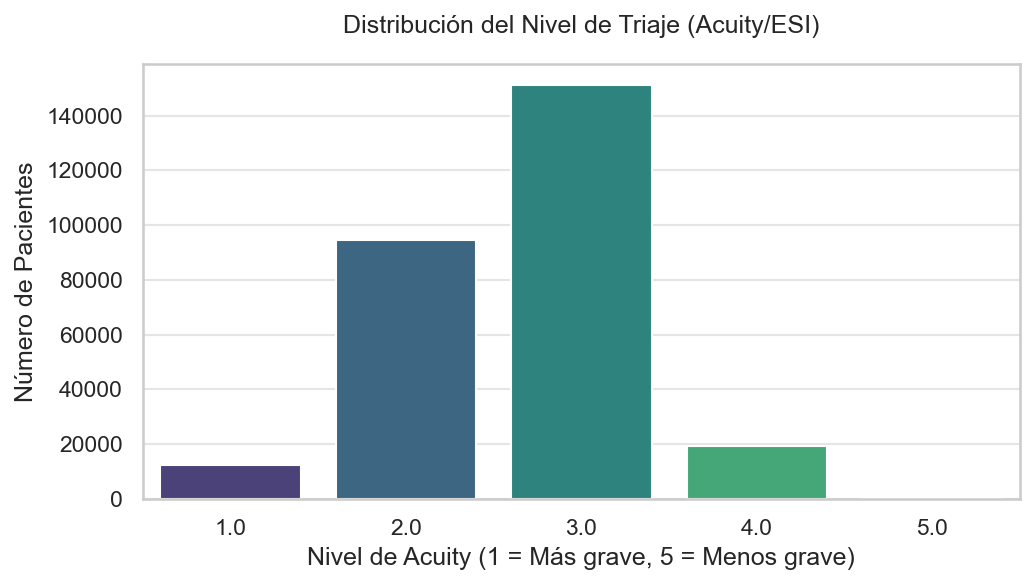

Proporción por Acuity:
acuity
1.0     4.442991
2.0    34.015119
3.0    54.345396
4.0     6.935523
5.0     0.260972
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df_train, x="acuity", palette="viridis")
plt.title("Distribución del Nivel de Triaje (Acuity/ESI)", pad=15)
plt.xlabel("Nivel de Acuity (1 = Más grave, 5 = Menos grave)")
plt.ylabel("Número de Pacientes")
plt.tight_layout()
plt.show()

print("Proporción por Acuity:")
print(df_train["acuity"].value_counts(normalize=True).sort_index() * 100)

## Correlación entre constantes vitales

Se verifica la estructura de correlación entre variables continuas del triaje. Correlaciones elevadas entre predictores pueden indicar redundancia o señal conjunta útil para el modelo.

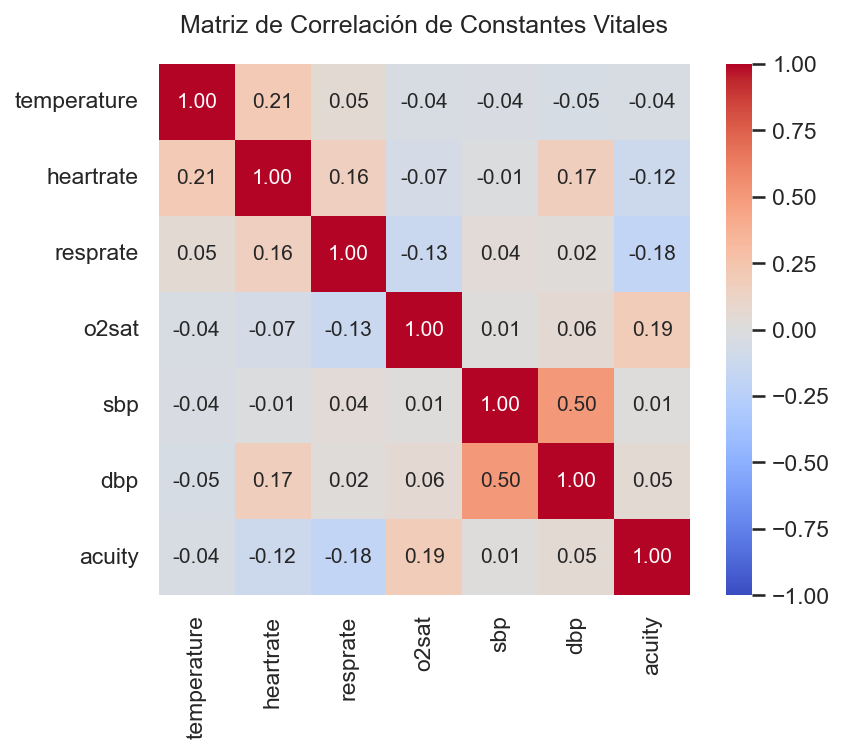

In [4]:
corr_matrix = df_train[vitals_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title("Matriz de Correlación de Constantes Vitales", pad=15)
plt.tight_layout()
plt.show()

## Relaciones bivariantes entre constantes vitales y etiquetas de resultado

Se comparan distribuciones de frecuencia cardiaca, saturación de O2 y presión sistólica según la presencia del outcome. Las diferencias observadas justifican la inclusión de estas variables como predictores primarios.

C:\Users\cuent\AppData\Local\Temp\ipykernel_22120\2323351176.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x="L2", y="heartrate", ax=axes[0], palette="Set2", showfliers=False)
C:\Users\cuent\AppData\Local\Temp\ipykernel_22120\2323351176.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x="L2", y="o2sat", ax=axes[1], palette="Set2", showfliers=False)
C:\Users\cuent\AppData\Local\Temp\ipykernel_22120\2323351176.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x="L1", y="sbp", ax=axes[2],

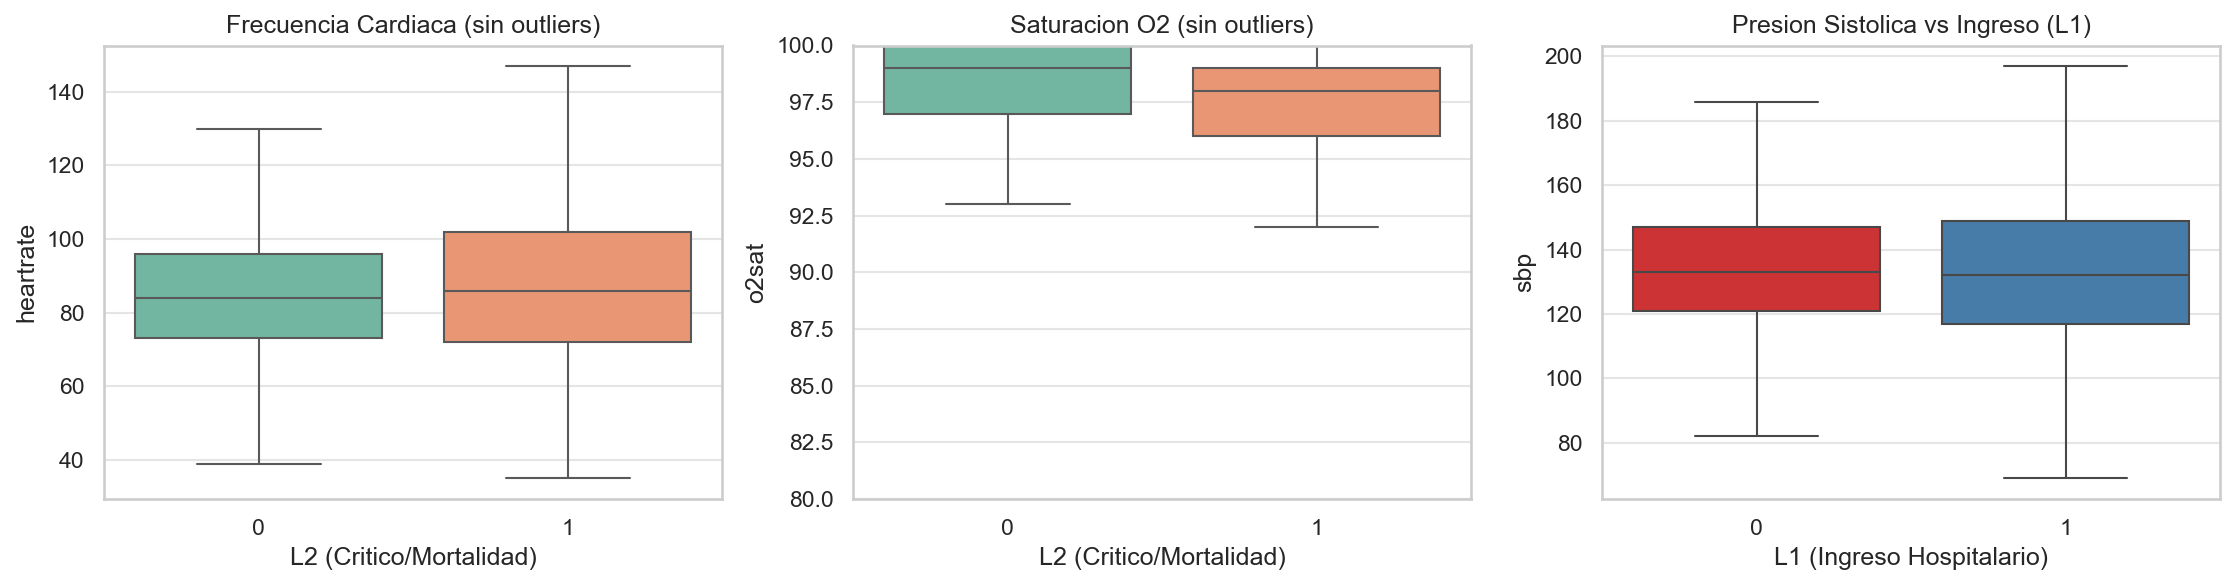

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Frecuencia cardiaca vs L2 (resultado critico)
sns.boxplot(data=df_train, x="L2", y="heartrate", ax=axes[0], palette="Set2", showfliers=False)
axes[0].set_title("Frecuencia Cardiaca (sin outliers)")
axes[0].set_xlabel("L2 (Critico/Mortalidad)")

# Saturacion de O2 vs L2
sns.boxplot(data=df_train, x="L2", y="o2sat", ax=axes[1], palette="Set2", showfliers=False)
axes[1].set_title("Saturacion O2 (sin outliers)")
axes[1].set_xlabel("L2 (Critico/Mortalidad)")
axes[1].set_ylim(80, 100)

# Presion sistolica vs L1 (ingreso hospitalario); edad no disponible en MIMIC-IV-ED
sns.boxplot(data=df_train, x="L1", y="sbp", ax=axes[2], palette="Set1", showfliers=False)
axes[2].set_title("Presion Sistolica vs Ingreso (L1)")
axes[2].set_xlabel("L1 (Ingreso Hospitalario)")

plt.tight_layout()
plt.show()